<a href="https://colab.research.google.com/github/Cami87029i/Inteligencia-Artificial-1/blob/main/Laboratorio5_3ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")


Dispositivo: cpu


In [ ]:
class ModeloPersonalizado(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(ModeloPersonalizado, self).__init__()
        self.fc1  = nn.Linear(D_in, H)
        self.relu = nn.ReLU()
        self.fc2  = nn.Linear(H, D_out)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

class ModelCustom2(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(ModelCustom2, self).__init__()
        self.fc1  = nn.Linear(D_in, H)
        self.relu = nn.ReLU()
        self.fc2  = nn.Linear(H, D_out)

    def forward(self, x):
        x1 = self.fc1(x)
        x  = self.relu(x1)
        x  = self.fc2(x + x1)  # conexión residual
        return x


In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b  = x_b.to(device), y_b.to(device)
            preds     = torch.argmax(model(x_b), axis=1)
            correct  += (preds == y_b).sum().item()
            total    += len(y_b)
    return correct / total * 100

def fit(model, train_loader, test_loader, epochs=20, PATH="./checkpoint.pt"):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0
    historial_loss = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x_b), y_b)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        epoch_loss = np.mean(losses)
        historial_loss.append(epoch_loss)

        val_acc = evaluate(model, test_loader)
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), PATH)
            print(f"Checkpoint guardado (val_acc: {val_acc:.2f}%)")

        print(f"Epoch {epoch}/{epochs}  loss: {epoch_loss:.5f}  val_acc: {val_acc:.2f}%")

    model.load_state_dict(torch.load(PATH))
    print(f"\n Listo. Mejor val_acc: {best_acc:.2f}%")
    return historial_loss

def guardar(model, PATH="./checkpoint.pt"):
    torch.save(model.state_dict(), PATH)
    print(f"Guardado en {PATH}")

def cargar(model, PATH="./checkpoint.pt"):
    model.load_state_dict(torch.load(PATH, map_location=device))
    model.eval()
    print(f"Cargado desde {PATH}")
    return model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Carga de datos ISOLET
# Primero descomprimimos los archivos desde Drive a la sesión local de Colab
path_train_z = "/content/drive/MyDrive/IA/isolet1+2+3+4.data.Z"
path_test_z = "/content/drive/MyDrive/IA/isolet5.data.Z"

# Descompresión (esto crea archivos temporales .csv en Colab)
!uncompress -c "{path_train_z}" > train_isolet.csv
!uncompress -c "{path_test_z}" > test_isolet.csv

# Cargamos los archivos resultantes con pandas
# ISOLET no tiene encabezados, por eso usamos header=None
train = pd.read_csv("train_isolet.csv", header=None)
test  = pd.read_csv("test_isolet.csv", header=None)

# Combinamos ambos datasets
data = pd.concat([train, test], ignore_index=True)

# En ISOLET, la ÚLTIMA columna es la etiqueta (label)
# Las primeras 617 columnas son las características (features)
X = data.iloc[:, :-1].values.astype(np.float32)
y = data.iloc[:, -1].values.astype(np.int64)

# Ajuste de etiquetas: ISOLET usa 1-26.
# Restamos 1 para que el rango sea 0-25 (estándar en redes neuronales)
if y.min() == 1:
    y = y - 1

input_layer_size = X.shape[1]  # Debería ser 617
num_labels       = 26          # Todas las letras del alfabeto (A-Z)
m                = len(y)

# Mapa de clases: índice 0 -> A, índice 1 -> B, ..., índice 25 -> Z
clases_unicas = np.unique(y)
mapa_clases   = {i: chr(65 + int(c)) for i, c in enumerate(clases_unicas)}

print(f"X: {X.shape}  |  y: {y.shape}")
print(f"Número de características (input_layer_size): {input_layer_size}")
print(f"Número de clases: {num_labels}")
print(f"Mapa de las primeras 5 clases: {{k: mapa_clases[k] for k in list(mapa_clases)[:5]}}")

X: (7797, 617)  |  y: (7797,)
Número de características (input_layer_size): 617
Número de clases: 26
Mapa de las primeras 5 clases: {k: mapa_clases[k] for k in list(mapa_clases)[:5]}


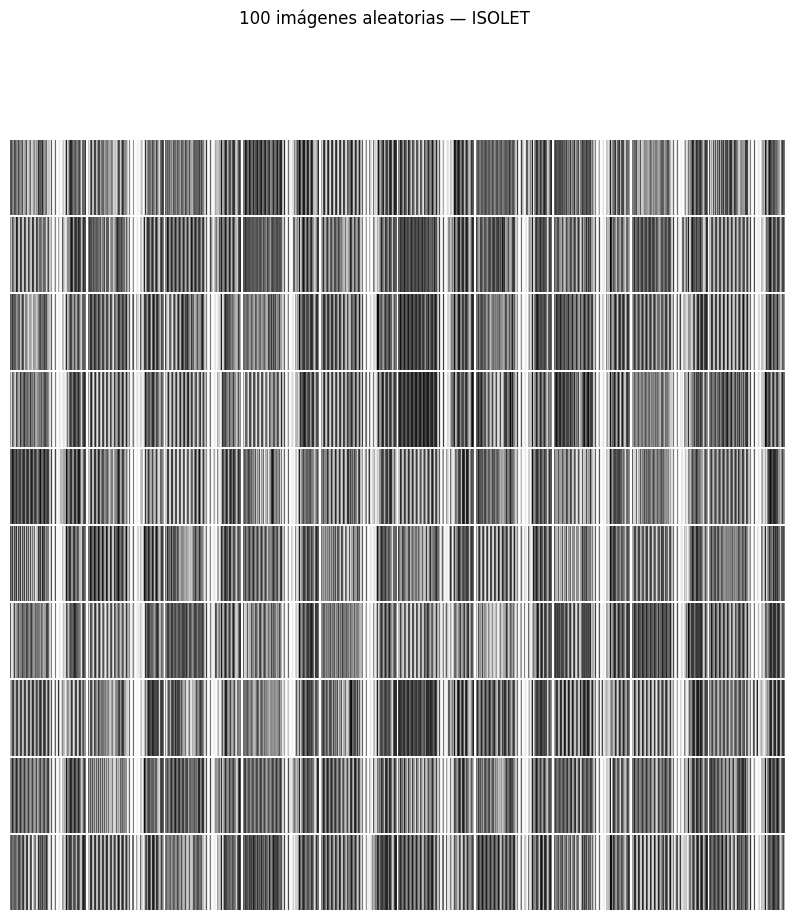

In [15]:
def displayData(X, figsize=(10, 10)):
    m            = X.shape[0]
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)
    ax_array = ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(1,617), cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')
    pyplot.suptitle('100 imágenes aleatorias — ISOLET', y=1.01)
    pyplot.show()

# 100 imágenes aleatorias del dataset original (sin normalizar)
rand_indices = np.random.choice(m, 100, replace=False)
displayData(X[rand_indices])


In [16]:
# Normalización: +1e-8 para evitar división por cero sin tirar columnas
mu    = X.mean(axis=0)
sigma = X.std(axis=0) + 1e-8
X     = (X - mu) / sigma

print(f"Normalización aplicada — media≈{mu.mean():.2f}  std≈{sigma.mean():.2f}")


Normalización aplicada — media≈0.06  std≈0.41


In [17]:
# Split 80/20 con sklearn — forma estándar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (6237, 617)  |  Test: (1560, 617)


Dataset y Dataloader

In [18]:
class SignDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

train_loader = DataLoader(SignDataset(X_train, y_train), batch_size=256, shuffle=True)
test_loader  = DataLoader(SignDataset(X_test,  y_test),  batch_size=256, shuffle=False)

print(f"D_in: {input_layer_size}  |  Batches train: {len(train_loader)}  |  Batches test: {len(test_loader)}")


D_in: 617  |  Batches train: 25  |  Batches test: 7


Modelo y entrenamiento

In [19]:
# D_in=784 píxeles, H=512 neuronas, D_out=24 clases (letras)
model = ModeloPersonalizado(input_layer_size, 512, num_labels).to(device)
print(model)
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


ModeloPersonalizado(
  (fc1): Linear(in_features=617, out_features=512, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=512, out_features=26, bias=True)
)
Parámetros totales: 329,754


In [20]:
historial_loss = fit(model, train_loader, test_loader, epochs=20, PATH="./sign_model.pt")

Checkpoint guardado (val_acc: 89.23%)
Epoch 1/20  loss: 1.16645  val_acc: 89.23%
Checkpoint guardado (val_acc: 92.95%)
Epoch 2/20  loss: 0.24062  val_acc: 92.95%
Epoch 3/20  loss: 0.13359  val_acc: 92.88%
Checkpoint guardado (val_acc: 94.36%)
Epoch 4/20  loss: 0.09190  val_acc: 94.36%
Epoch 5/20  loss: 0.06714  val_acc: 94.36%
Checkpoint guardado (val_acc: 95.06%)
Epoch 6/20  loss: 0.04718  val_acc: 95.06%
Checkpoint guardado (val_acc: 95.26%)
Epoch 7/20  loss: 0.03547  val_acc: 95.26%
Epoch 8/20  loss: 0.02623  val_acc: 95.19%
Checkpoint guardado (val_acc: 95.51%)
Epoch 9/20  loss: 0.01942  val_acc: 95.51%
Checkpoint guardado (val_acc: 95.64%)
Epoch 10/20  loss: 0.01507  val_acc: 95.64%
Checkpoint guardado (val_acc: 95.90%)
Epoch 11/20  loss: 0.01222  val_acc: 95.90%
Epoch 12/20  loss: 0.00993  val_acc: 95.83%
Epoch 13/20  loss: 0.00834  val_acc: 95.90%
Epoch 14/20  loss: 0.00792  val_acc: 95.77%
Epoch 15/20  loss: 0.00652  val_acc: 95.90%
Checkpoint guardado (val_acc: 95.96%)
Epoch 1

Gráfica 2 :Convergencia del costo por época

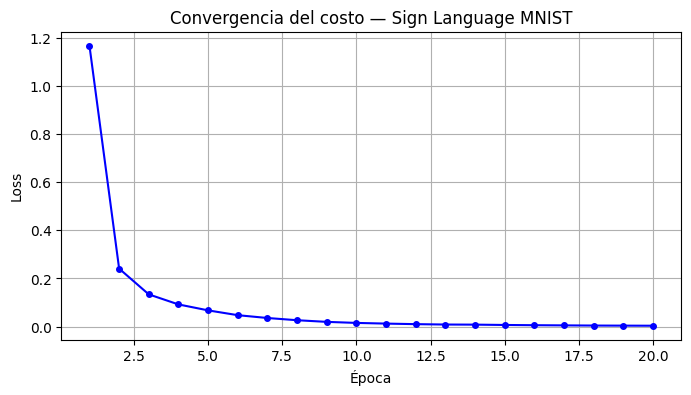

In [21]:
# Evolución del loss durante el entrenamiento
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(1, len(historial_loss) + 1), historial_loss, 'b-o', markersize=4)
pyplot.xlabel('Época')
pyplot.ylabel('Loss')
pyplot.title('Convergencia del costo — Sign Language MNIST')
pyplot.grid(True)
pyplot.show()

Gráfica 3

  Letra A: 96.97%
  Letra B: 92.00%
  Letra C: 96.77%
  Letra D: 91.53%
  Letra E: 93.75%
  Letra F: 98.31%
  Letra G: 94.34%
  Letra H: 100.00%
  Letra I: 100.00%
  Letra J: 98.18%
  Letra K: 97.44%
  Letra L: 100.00%
  Letra M: 94.83%
  Letra N: 90.91%
  Letra O: 100.00%
  Letra P: 88.14%
  Letra Q: 98.33%
  Letra R: 98.08%
  Letra S: 98.39%
  Letra T: 94.44%
  Letra U: 96.08%
  Letra V: 89.47%
  Letra W: 98.15%
  Letra X: 100.00%
  Letra Y: 98.55%
  Letra Z: 92.54%


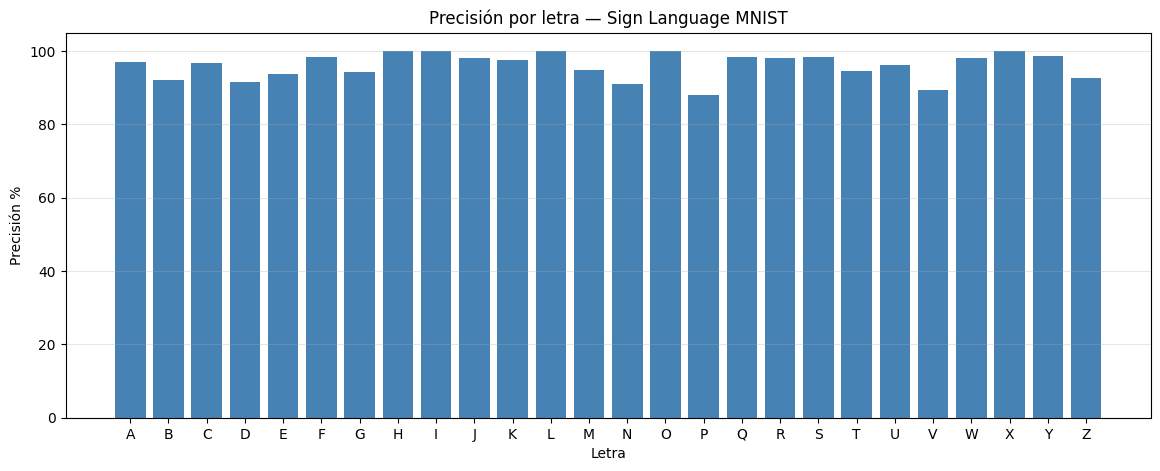

In [22]:
# Precisión por clase
all_preds, all_true = [], []
model.eval()
with torch.no_grad():
    for x_b, y_b in test_loader:
        preds = torch.argmax(model(x_b.to(device)), axis=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_b.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

precisiones = []
for c in range(num_labels):
    mask = (all_true == c)
    prec = np.mean(all_preds[mask] == all_true[mask]) * 100 if mask.sum() > 0 else 0
    precisiones.append(prec)
    print(f"  Letra {mapa_clases[c]}: {prec:.2f}%")

pyplot.figure(figsize=(14, 5))
pyplot.bar([mapa_clases[c] for c in range(num_labels)], precisiones, color='steelblue')
pyplot.xlabel('Letra')
pyplot.ylabel('Precisión %')
pyplot.title('Precisión por letra — Sign Language MNIST')
pyplot.ylim(0, 105)
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()

In [23]:
print(f"Accuracy final: {evaluate(model, test_loader):.2f}%")

Accuracy final: 96.09%


Evaluación y predicciones individuales

12 predicciones vs valores reales:
  Ejemplo  1: H  |  Real: H  good
  Ejemplo  2: R  |  Real: R  good
  Ejemplo  3: A  |  Real: A  good
  Ejemplo  4: S  |  Real: S  good
  Ejemplo  5: Y  |  Real: Y  good
  Ejemplo  6: K  |  Real: K  good
  Ejemplo  7: R  |  Real: R  good
  Ejemplo  8: L  |  Real: L  good
  Ejemplo  9: T  |  Real: T  good
  Ejemplo 10: X  |  Real: X  good
  Ejemplo 11: Q  |  Real: Q  good
  Ejemplo 12: R  |  Real: R  good


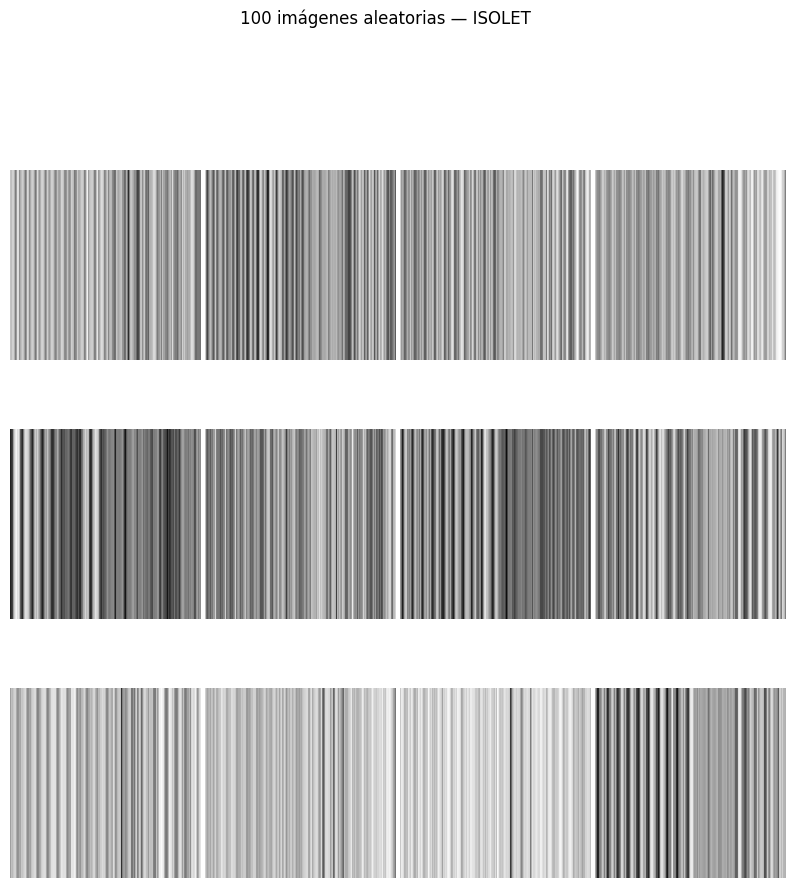

In [24]:
# 10 predicciones individuales con visualización
muestra_X = torch.from_numpy(X_test[:12]).float()
muestra_y = y_test[:12]

model.eval()
with torch.no_grad():
    preds = torch.argmax(model(muestra_X.to(device)), axis=1).cpu().numpy()

print("12 predicciones vs valores reales:")
for i, (pred, real) in enumerate(zip(preds, muestra_y)):
    letra_pred = mapa_clases.get(pred, '?')
    letra_real = mapa_clases.get(real, '?')
    ok = "good" if pred == real else "bad"
    print(f"  Ejemplo {i+1:2d}: {letra_pred}  |  Real: {letra_real}  {ok}")

# Visualizar las imágenes correspondientes
displayData(X_test[:12])


In [25]:
guardar(model, "./sign.pt")

Guardado en ./sign.pt
